Module 3: Statistics Assessment

In [ ]:
Statistics Project 
Customer Behavior Analysis
Analyze customer behavior using statistical and mathematical tools in Python.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [15]:
df = pd.read_csv("C:\\Users\\silpa\\Downloads\\customer_behavior.csv")

In [16]:
df.head()

,CustomerID,Gender,Region,PurchaseAmount,ProductCategory,Churn,CampaignGroup
0,1001,Male,South,256.07,Fashion,No,A
1,1002,Female,South,NaN,Electronics,Yes,B
2,1003,Female,West,1194.41,Fashion,No,A
3,1004,Female,South,413.06,Grocery,No,A
4,1005,Male,West,1556.32,Fashion,Yes,A


In [18]:
print('Shape:', df.shape)
print('Missing values:\n', df.isnull().sum())

Shape: (5000, 7)
Missing values:
 CustomerID           0
Gender              97
Region             175
PurchaseAmount     150
ProductCategory    526
Churn              265
CampaignGroup      185
dtype: int64


In [19]:
x = df['PurchaseAmount'].dropna()

In [20]:
print('Mean:', x.mean())
print('Median:', x.median())
print('Mode:', x.mode().tolist())

Mean: 1003.9506701030928
Median: 998.0799999999999
Mode: [0.0]


In [21]:
Q1 = x.quantile(0.25)
Q3 = x.quantile(0.75)

In [22]:
IQR = Q3-Q1
lower_bound = Q1-1.5*IQR
upper_bound = Q3+1.5*IQR
outliers = x[(x<lower_bound)|(x>upper_bound)]

In [23]:
print('Q1:',Q1,'Q3:',Q3,'IQR:',IQR)
print('Lower bound:',lower_bound,'Upper bound:',upper_bound)
print('Number of outliers:',len(outliers))

Q1: 673.6424999999999 Q3: 1327.0775 IQR: 653.4350000000002
Lower bound: -306.51000000000033 Upper bound: 2307.2300000000005
Number of outliers: 15


In [24]:
print('Skewness:', stats.skew(x,bias=False))
print('Excess kurtosis:', stats.kurtosis(x,bias=False))

Skewness: 0.10609189374631554
Excess kurtosis: -0.2615105545319709


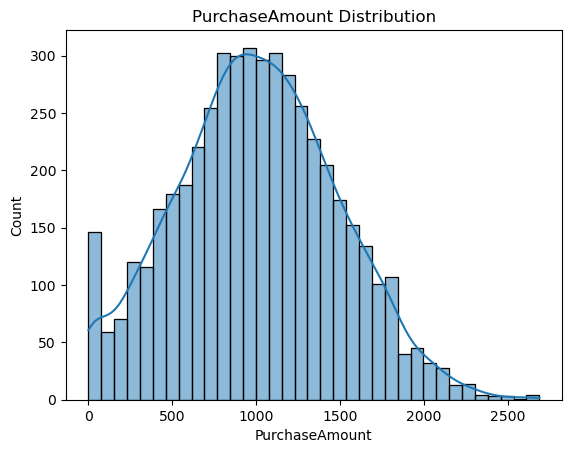

In [25]:
sns.histplot(x,kde=True)
plt.title('PurchaseAmount Distribution')
plt.show()

In [26]:
male = df.loc[df['Gender']=='Male','PurchaseAmount'].dropna()
female = df.loc[df['Gender']=='Female','PurchaseAmount'].dropna()

In [27]:
print('Male mean:',male.mean())
print('Female mean:',female.mean())
print(stats.ttest_ind(male,female,equal_var=False))

Male mean: 1019.1766093880973
Female mean: 987.8720464135021
TtestResult(statistic=np.float64(2.234798912073049), pvalue=np.float64(0.025476849797238143), df=np.float64(4752.426452260987))


In [28]:
table = pd.crosstab(df['ProductCategory'],df['Churn'])

In [29]:
print(table)
print(stats.chi2_contingency(table)[:3])

Churn             No  Yes
ProductCategory          
Electronics      785  541
Fashion          839  607
Grocery          855  604
(np.float64(0.3960436652673918), np.float64(0.8203519424988512), 2)


In [30]:
print(df.groupby('Region')['PurchaseAmount'].mean())
groups = [g['PurchaseAmount'].dropna() for _,g in df.groupby('Region')]
print(stats.f_oneway(*groups))

Region
East     1009.946017
North    1013.017952
South     997.603877
West      995.247327
Name: PurchaseAmount, dtype: float64
F_onewayResult(statistic=np.float64(0.38966786354806715), pvalue=np.float64(0.760452802731563))


In [31]:
campaign_stats = df.groupby('CampaignGroup')['PurchaseAmount'].agg(['count','mean','std'])
print(campaign_stats)

               count         mean         std
CampaignGroup                                
A               2350  1011.945587  480.160915
B               2318   994.339965  487.383742


In [ ]:
stat,p = stats.shapiro(x)

In [33]:
print('Shapiro statistic:',stat)
print('p-value:',p)

Shapiro statistic: 0.9949505740555433
p-value: 5.744127799493938e-12


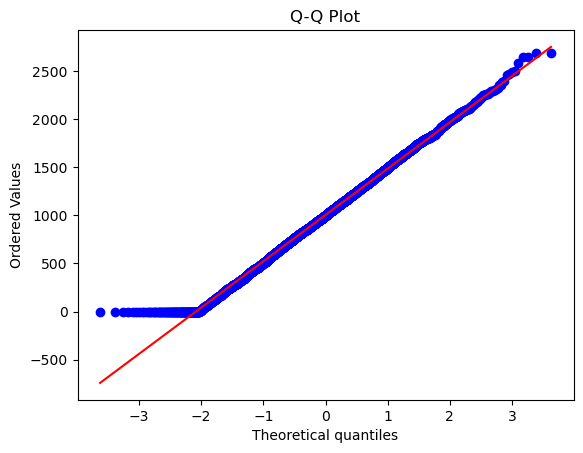

In [34]:
stats.probplot(x,dist='norm',plot=plt)
plt.title('Q-Q Plot')
plt.show()

In [35]:
sample_means=[]
for i in range(1000):
    sample=x.sample(30,replace=True,random_state=i)
    sample_means.append(sample.mean())

In [36]:
print('Mean of sample means:',np.mean(sample_means))
print('SD of sample means:',np.std(sample_means,ddof=1))

Mean of sample means: 1000.9630746666667
SD of sample means: 89.97633048246858


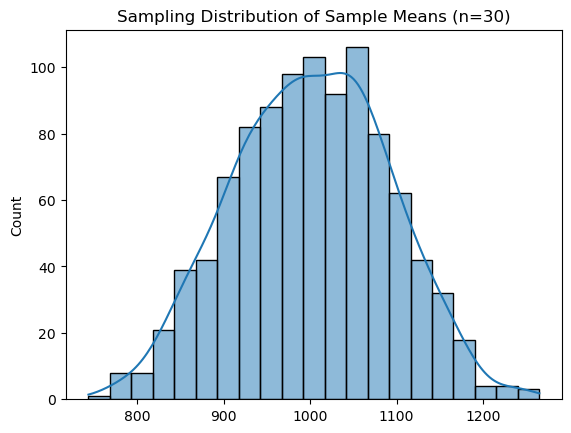

In [37]:
sns.histplot(sample_means,kde=True)
plt.title('Sampling Distribution of Sample Means (n=30)')
plt.show()

In [38]:
ci = stats.t.interval(0.95,df=len(x)-1,loc=x.mean(),scale=stats.sem(x))
print('95% confidence interval:',ci)

95% confidence interval: (np.float64(990.3789594609216), np.float64(1017.522380745264))
